<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/05_varying_intercept_slope.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 5 — Varying intercepts and slopes

Notebook 4 introduced a hierarchical model in detail. Here the full model is supplied up front.

The new task is to **read a hierarchical model**, run the familiar Bayesian workflow, and identify which posterior quantities answer particular questions.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

participants = sorted(sleep["Subject"].unique(), key=int)
participant_to_idx = {participant: i for i, participant in enumerate(participants)}
participant_idx = sleep["Subject"].map(participant_to_idx).to_numpy()

assert participant_idx.min() == 0
assert participant_idx.max() == len(participants) - 1
assert np.array_equal(
    np.asarray(participants)[participant_idx],
    sleep["Subject"].to_numpy(),
)

print(f"{len(participants)} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helper

The participant plotting helper is supplied. It can optionally restrict plots to selected participants using the standard ArviZ `coords` argument.

In [4]:
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}

PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_participants(dt, group, var, coords=None):
    """One panel per participant, optionally restricted with ArviZ coords."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        coords=coords,
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")
    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    return pc

## 1. Read the varying-intercept, varying-slope model

### 1.1 The model

The full model is supplied:

$$
y_i \sim \operatorname{Normal}(\mu_{y,i}, sd_y)
$$

$$
\mu_{y,i}
=
b_{0,s[i]}
+
b_{1,s[i]}\,\mathrm{days}_i
$$

$$
b_{0,s}
\sim
\operatorname{Normal}(\mu_{b0}, sd_{b0})
$$

$$
b_{1,s}
\sim
\operatorname{Normal}(\mu_{b1}, sd_{b1}).
$$

The intercept and slope hierarchies are independent in this short-course model. This is a deliberate simplification: it allows participant baselines and sleep-deprivation effects to vary, but it does not estimate whether those two characteristics are correlated across participants.

### 1.2 The complete PyMC implementation

The intercept hierarchy is the same one introduced in Notebook 4. The new slope hierarchy follows the same pattern: a population center, a between-participant standard deviation, and one partially pooled slope per participant.

In [5]:
coords = {
    "obs_id": np.arange(len(sleep)),
    "participant": participants,
}

# Hyperprior constants for the intercept hierarchy
mu_mu_b0 = 250
sd_mu_b0 = 100
sd_sd_b0 = 25

# Hyperprior constants for the slope hierarchy
mu_mu_b1 = 0
sd_mu_b1 = 20
sd_sd_b1 = 10

# Prior constant for observation-level variation
mu_sd_y = 50

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    # Varying intercepts
    mu_b0 = pm.Normal("mu_b0", mu=mu_mu_b0, sigma=sd_mu_b0)
    sd_b0 = pm.Exponential("sd_b0", scale=sd_sd_b0)
    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0, dims="participant")

    # Varying slopes
    mu_b1 = pm.Normal("mu_b1", mu=mu_mu_b1, sigma=sd_mu_b1)
    sd_b1 = pm.Exponential("sd_b1", scale=sd_sd_b1)
    b1 = pm.Normal(
        "b1",
        mu=mu_b1,
        sigma=sd_b1,
        dims="participant",
    )

    # Useful derived quantity: expected change across all seven days
    change_7 = pm.Deterministic(
        "change_7",
        7 * b1,
        dims="participant",
    )

    # Likelihood
    sd_y = pm.Exponential("sd_y", scale=mu_sd_y)
    mu_y = pm.Deterministic(
        "mu_y",
        b0[pidx] + b1[pidx] * days,
        dims="obs_id",
    )
    y = pm.Normal(
        "y",
        mu=mu_y,
        sigma=sd_y,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

print(model)

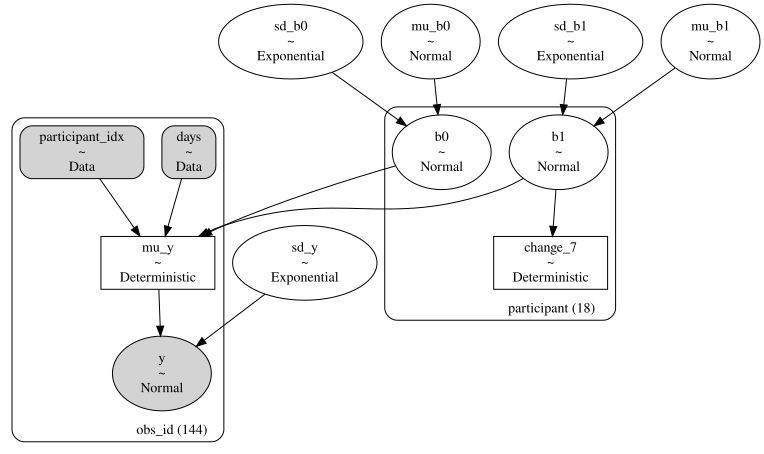

In [6]:
pm.model_to_graphviz(model)

### 1.3 Which quantities vary by participant?

Which model variables contain one value for every participant?

`b0`, `b1`, and `change_7` each contain one value per participant.

### 1.4 Which parameter is the population-average sleep-deprivation slope?

Name the parameter that represents the average change in expected reaction time per day across participants.

`mu_b1`.

### 1.5 Which parameters describe the population distribution of slopes?

Which parameter gives its center, and which gives its between-participant scale?

`mu_b1` is the center of the population distribution, and `sd_b1` is its between-participant standard deviation.

### 1.6 What controls the size of participant slope differences?

Which parameter controls how widely participant slopes vary around the population mean?

`sd_b1`.

### 1.7 What exchangeability assumption does the slope hierarchy make?

What does the model assume about the relationship between participant labels and their slopes before seeing the data?

The participant slopes are treated as exchangeable draws from one common population distribution. Their labels do not impose an ordering or make one participant intrinsically more variable than another.

### 1.8 Must `mu_b1` equal the average of these 18 participant slopes?

Distinguish the center of the population distribution from the realized average of this finite sample of participants.

No. `mu_b1` is the center of the population distribution from which participant slopes are modeled as draws. The average of the 18 realized participant slopes can differ from that population center.

### 1.9 Which participant-specific quantities determine `mu_y`?

Name the two participant-specific regression parameters selected by `participant_idx`.

The participant-specific intercept `b0[pidx]` and slope `b1[pidx]`.

### 1.10 What is the difference between `mu_y` and `y`?

Which one is expected reaction time and which one includes observation-level variation?

`mu_y` is the expected reaction time for each observation. `y` is a possible observed reaction time and also includes residual variation controlled by `sd_y`.

### 1.11 What does `change_7` represent?

Give its units and interpretation.

`change_7` is the expected change in reaction time from day 0 to day 7 for each participant, measured in milliseconds.

## 2. Check the prior implications

### 2.1 Criteria

The slope hierarchy should:

- allow a broad range of plausible population-average sleep-deprivation effects;
- allow meaningful participant-to-participant variation in slopes;
- avoid making enormous seven-day changes routine.

The full prior predictive distribution should also satisfy the general plausibility criteria established in the earlier notebooks.

### 2.2 Draw from the prior and inspect the new slope hierarchy.

Sampling: [b0, b1, mu_b0, mu_b1, sd_b0, sd_b1, sd_y, y]


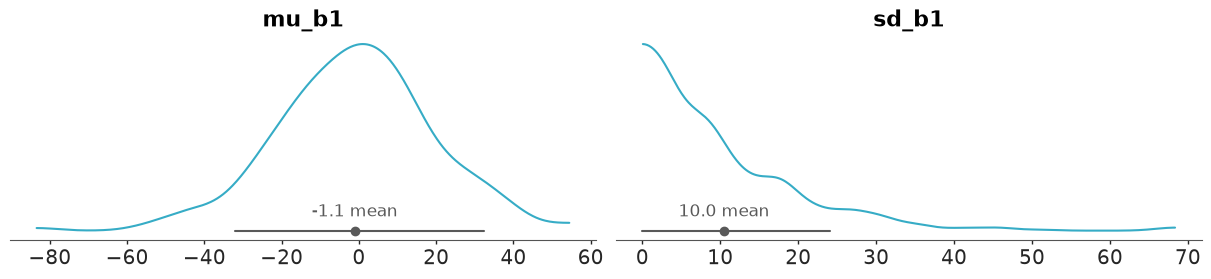

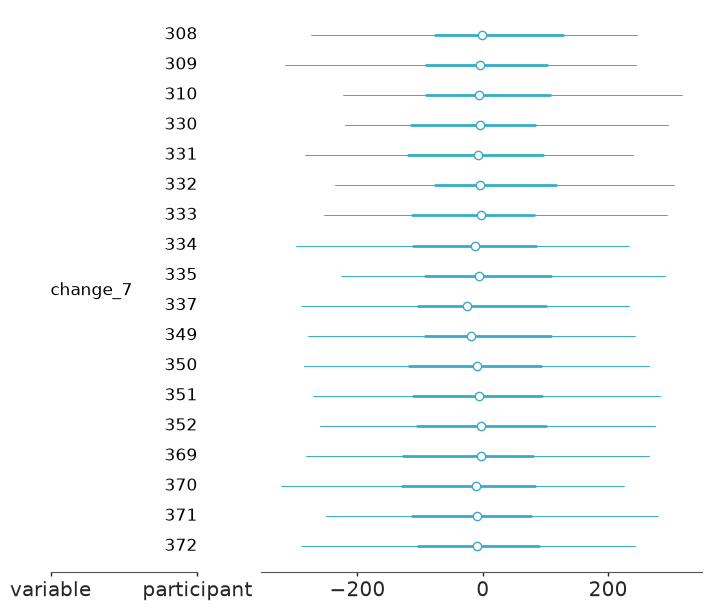

In [7]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=[
            "mu_b1",
            "sd_b1",
            "b1",
            "change_7",
            "mu_y",
            "y",
        ],
        random_seed=RANDOM_SEED,
    )

azp.plot_dist(
    prior,
    group="prior",
    var_names=["mu_b1", "sd_b1"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

azp.plot_forest(
    prior,
    group="prior",
    var_names=["change_7"],
    combined=True,
    ci_probs=(0.50, 0.90),
    ci_kind="hdi",
    figure_kwargs={"figsize": (7, 6)},
);

### 2.3 Are the slope priors reasonable?

Do the plotted priors allow meaningful differences in seven-day change without making implausibly enormous changes routine?

The priors are deliberately permissive. The 90% intervals for seven-day change span several hundred milliseconds for many participants, so the hierarchy clearly allows meaningful slope differences. Those wide intervals also place the prior near the edge of what is scientifically plausible; this is a broad teaching prior, not a generally recommended default.

### 2.4 Generate and plot prior predictive reaction times.

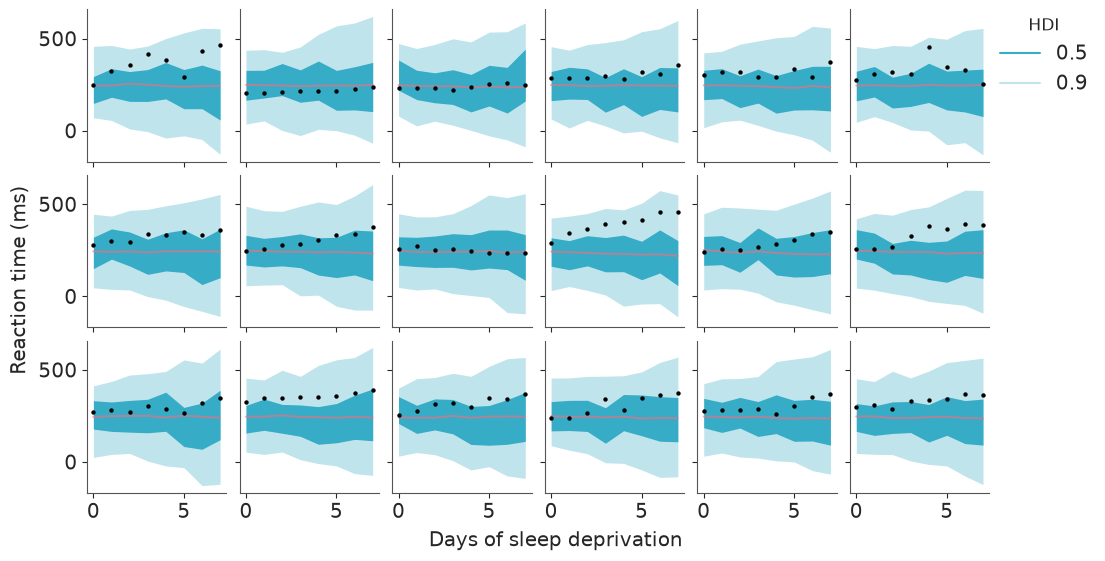

In [8]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 2.5 Do the prior predictive simulations satisfy the established criteria?

Judge support, baseline scale, changes across days, and participant-to-participant variation.

Broadly, but with an important warning. The prior predictive distribution allows different participant levels and slopes, but its 90% bands reach below zero for some late-day predictions and extend to very large reaction times. Physically impossible values are not central predictions, yet the Gaussian likelihood and deliberately broad priors make them possible. We will proceed while retaining that limitation rather than treating the prior check as an unqualified pass.

## 3. Fit and diagnose the model

### 3.1 Sample from the posterior.

In [9]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [mu_b0, sd_b0, b0, mu_b1, sd_b1, b1, sd_y]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 7 seconds.


### 3.2 Check population-level diagnostics.

In [10]:
print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))

population_summary = azs.summary(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)
population_summary

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_b0,267.89,8.79,253.45,282.15,5147.08,2983.69,1.0,0.12,0.15
sd_b0,32.50,6.97,21.26,43.09,3541.41,2882.12,1.0,0.11,0.11
mu_b1,11.30,2.05,8.07,14.62,5124.22,3249.22,1.0,0.03,0.04
sd_b1,7.34,1.72,4.61,9.96,3065.00,2718.52,1.0,0.03,0.03
sd_y,25.76,1.76,22.79,28.52,4728.32,3442.33,1.0,0.03,0.03


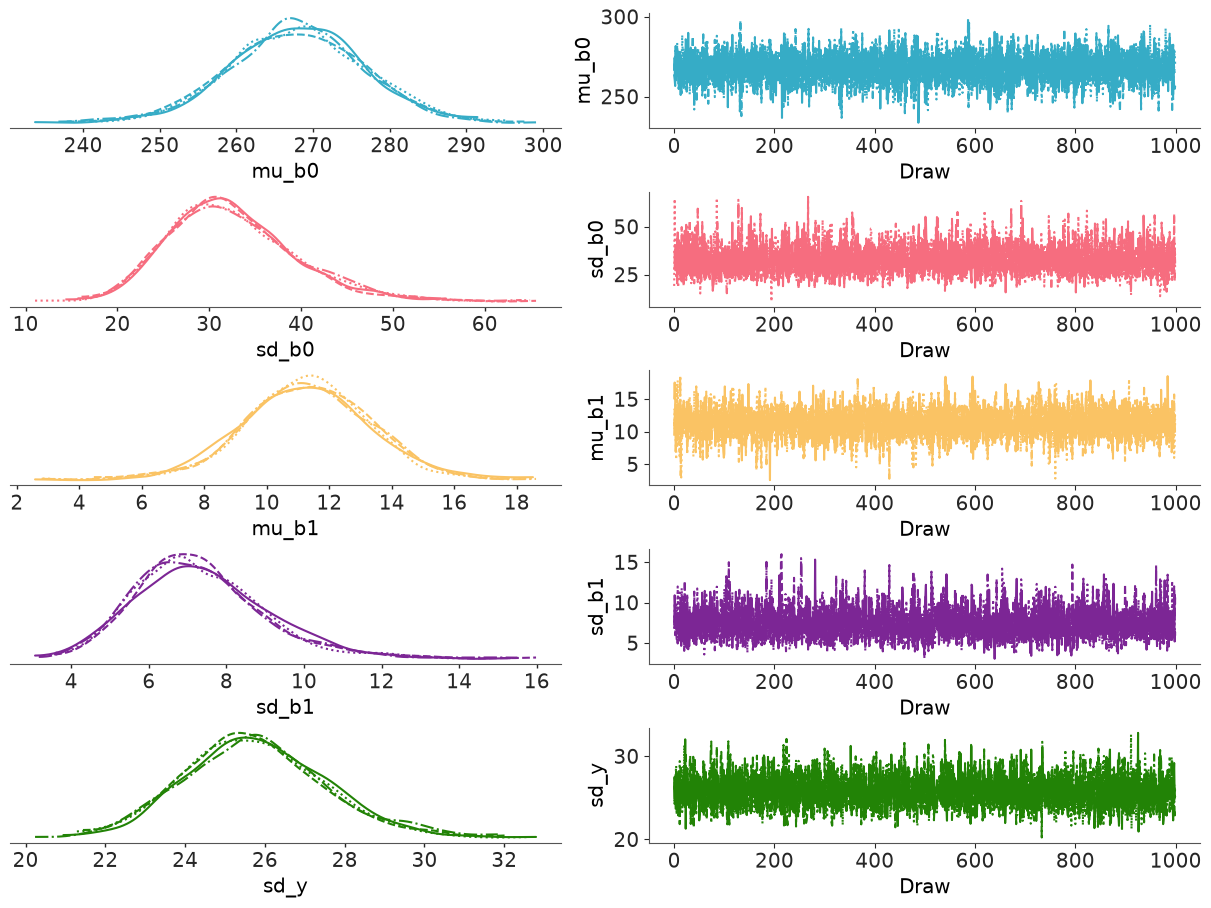

In [11]:
azp.plot_trace_dist(
    idata,
    var_names=["mu_b0", "sd_b0", "mu_b1", "sd_b1", "sd_y"],
);

### 3.3 Do the population-level parameters meet the diagnostic criteria?

Use the same criteria established in Notebook 1: no divergences, R-hat close to 1, adequate bulk and tail ESS, and well-mixed traces.

Yes. There are no divergences, every reported population-level R-hat is 1.00, and the bulk and tail ESS values are all comfortably above 2,800. The trace plots also show well-mixed chains. The centered hierarchy is computationally reliable for these data.

### 3.4 Inspect a small subset of participant effects.

In [12]:
participant_diagnostics = azs.summary(
    idata,
    var_names=["b0", "b1"],
    kind="diagnostics",
    round_to=2,
)

display(pd.DataFrame(
    {
        "value": [
            participant_diagnostics["r_hat"].max(),
            participant_diagnostics["ess_bulk"].min(),
            participant_diagnostics["ess_tail"].min(),
        ]
    },
    index=["largest R-hat", "smallest bulk ESS", "smallest tail ESS"],
))

diagnostic_participants = [
    participants[0],
    participants[len(participants) // 2],
    participants[-1],
]
diagnostic_coords = {"participant": diagnostic_participants}

azs.summary(
    idata,
    var_names=["b0", "b1"],
    coords=diagnostic_coords,
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

,value
largest R-hat,1.00
smallest bulk ESS,4365.93
smallest tail ESS,2819.08


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0[308],291.66,14.30,269.61,316.38,4700.76,3288.83,1.0,0.21,0.21
b0[337],312.01,14.81,287.17,336.09,4887.46,3268.69,1.0,0.21,0.21
b0[372],286.26,14.26,262.11,309.14,6318.31,3464.96,1.0,0.18,0.24
b1[308],20.15,3.46,14.47,25.80,4685.28,3206.58,1.0,0.05,0.05
b1[337],21.59,3.48,16.07,27.48,4365.93,3354.45,1.0,0.05,0.05
b1[372],11.94,3.40,6.34,17.58,6272.42,2819.08,1.0,0.04,0.06


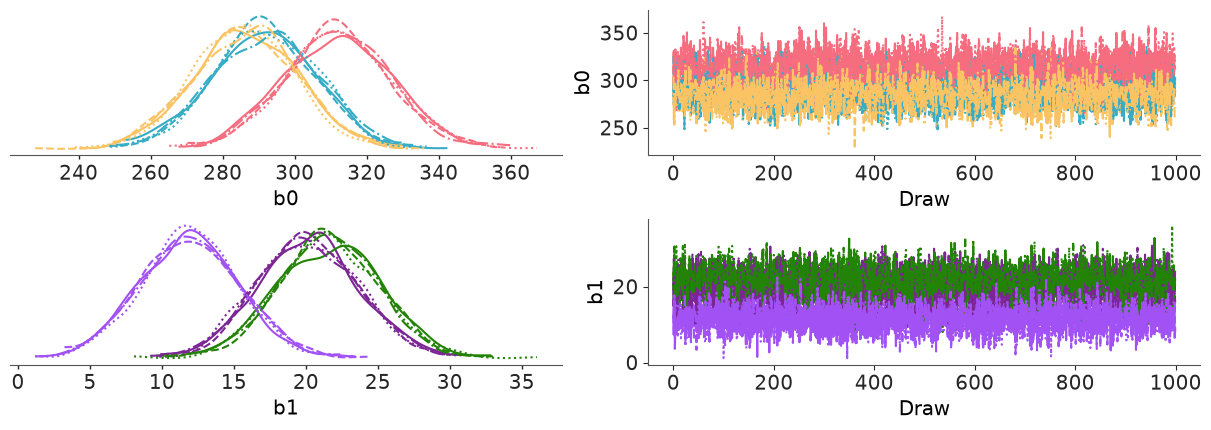

In [13]:
azp.plot_trace_dist(
    idata,
    var_names=["b0", "b1"],
    coords=diagnostic_coords,
);

### 3.5 Do the displayed participant-level parameters meet the same criteria?

Yes. The all-participant screen shows no problematic R-hat or ESS value, and the displayed intercept and slope traces for participants 308, 337, and 372 mix well. Their individual R-hat values are 1.00 with large effective sample sizes.

## 4. Examine the fitted slope hierarchy

### 4.1 Which parameter gives the population-average daily sleep-deprivation effect?

`mu_b1`.

### 4.2 Plot the posterior distribution of that parameter.

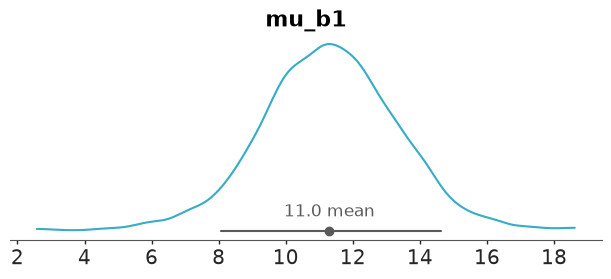

In [14]:
azp.plot_dist(
    idata,
    var_names=["mu_b1"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 4.3 What range of population-average daily effects is credible?

Use the 90% HDI from the posterior summary.

The 90% HDI for `mu_b1` is approximately **7.94–14.71 ms/day**. Under this model, the population distribution is centered on a clearly positive daily slowing effect.

### 4.4 Which parameter controls participant-to-participant variation in slopes?

`sd_b1`.

### 4.5 Plot its posterior distribution.

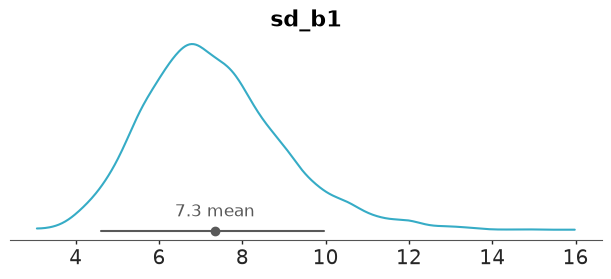

In [15]:
azp.plot_dist(
    idata,
    var_names=["sd_b1"],
    ci_prob=0.90,
    ci_kind="hdi",
    point_estimate="mean",
);

### 4.6 What range of slope-variation scales is credible?

Use the 90% HDI for `sd_b1`.

The 90% HDI for `sd_b1` is approximately **4.74–10.06 ms/day**. This is the inferred between-participant standard deviation of daily sleep-deprivation effects.

### 4.7 Which posterior variable contains the participant-specific slopes?

`b1`.

### 4.8 Plot the participant-specific slopes.

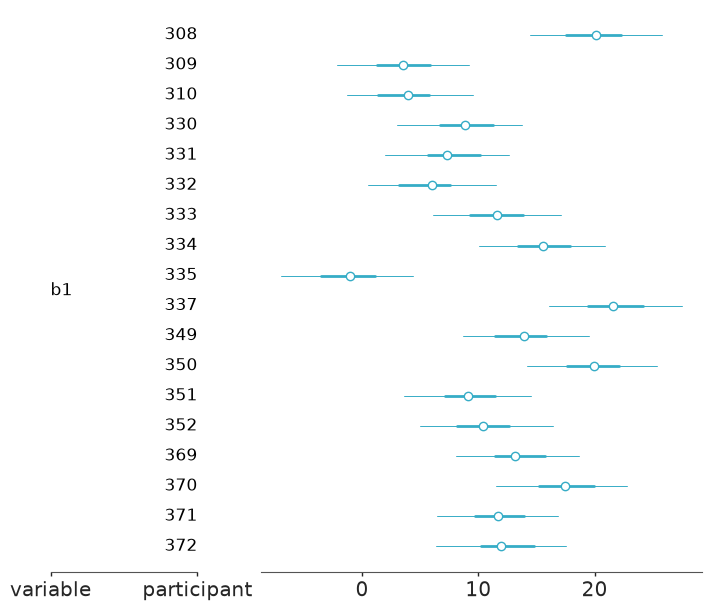

In [16]:
azp.plot_forest(
    idata,
    var_names=["b1"],
    combined=True,
    ci_probs=(0.50, 0.90),
    ci_kind="hdi",
    figure_kwargs={"figsize": (7, 6)},
);

### 4.9 Does the fitted model support meaningful heterogeneity in sleep-deprivation effects?

Base the answer on the participant intervals and the posterior for `sd_b1`.

Yes. The posterior for `sd_b1` is well above zero, and the participant slope intervals occupy visibly different regions. Some participants have slopes near zero, while others are around 20 ms/day or higher. The data therefore support meaningful heterogeneity in sleep-deprivation effects.

### 4.10 Which variable gives each participant's expected seven-day change?

`change_7`.

### 4.11 Plot those participant-specific seven-day changes.

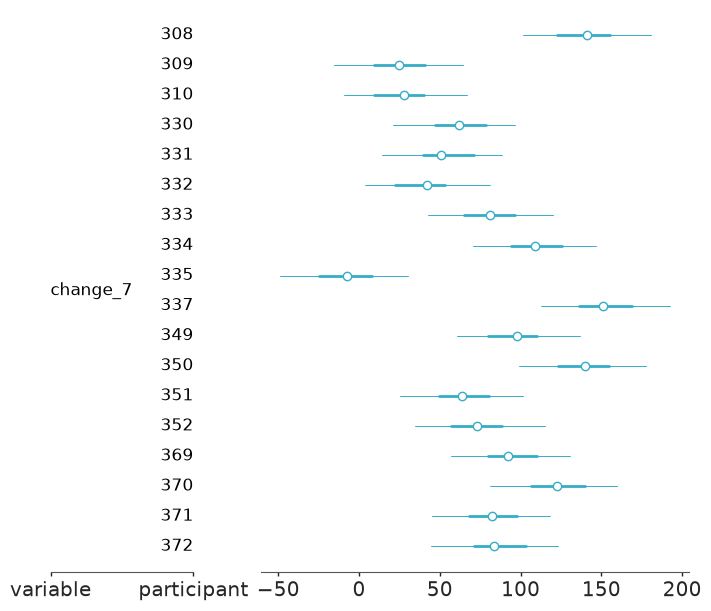

In [17]:
azp.plot_forest(
    idata,
    var_names=["change_7"],
    combined=True,
    ci_probs=(0.50, 0.90),
    ci_kind="hdi",
    figure_kwargs={"figsize": (7, 6)},
);

## 5. Examine expected participant trajectories

### 5.1 Which variable represents expected reaction time without residual observation noise?

`mu_y`.

### 5.2 Plot the posterior expected trajectories.

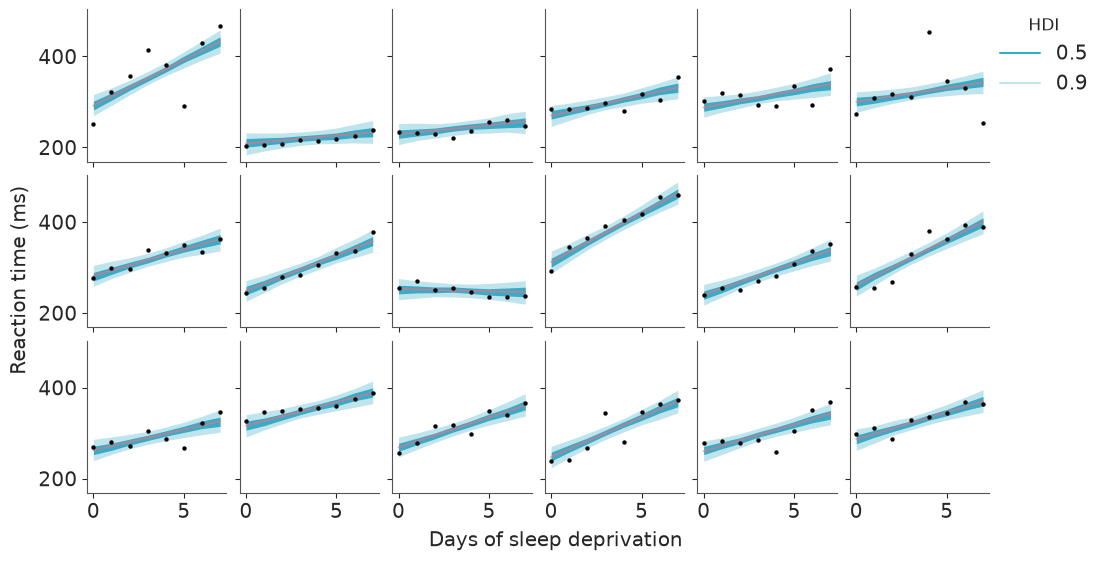

In [18]:
plot_participants(idata, "posterior", "mu_y")
plt.show()

### 5.3 Can expected participant trajectories now differ in both baseline and rate of change?

Yes. `b0` varies by participant and `b1` also varies by participant, so expected trajectories can differ in both intercept and slope.

## 6. Posterior predictive check — participant trajectories

### 6.1 Generate and plot posterior predictive reaction times.

Sampling: [y]


Output()

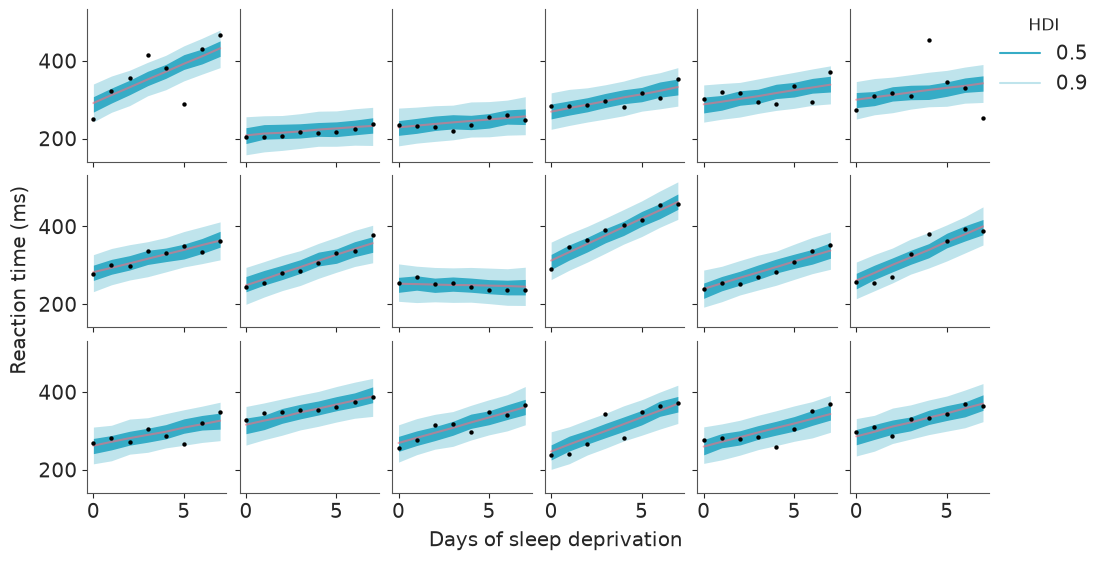

In [19]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 6.2 What is added when we move from `mu_y` to posterior predictive `y`?

Posterior predictive `y` includes residual observation-level variation controlled by `sd_y`; `mu_y` does not.

### 6.3 Does the model reproduce participant-to-participant differences in trajectories?

Check both overall level and change across days.

Yes, substantially better than the common-slope model. The predictive bands now follow persistent differences in both participant level and rate of change. Isolated observations still miss the central bands, but the systematic trajectory mismatches are much smaller.

## 7. Posterior predictive check — overall distribution

### 7.1 Why make another posterior predictive plot?

The participant panels primarily check the conditional trajectories.

We now pool all observations and ask a different question: does the Gaussian likelihood reproduce the overall distribution of reaction times?

### 7.2 Plot the observed and posterior-predictive ECDFs.

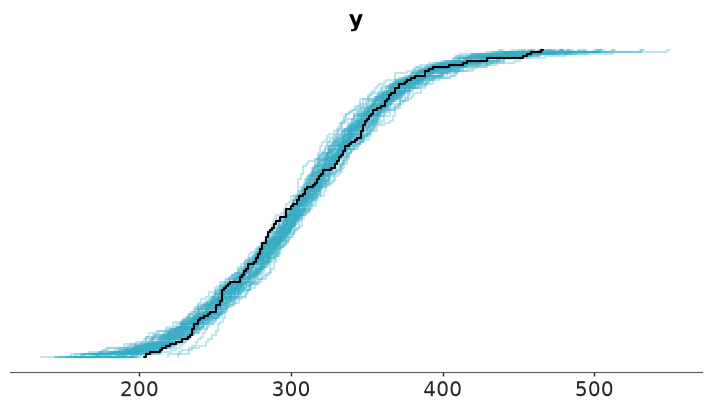

In [20]:
azp.plot_ppc_dist(
    idata,
    var_names=["y"],
    kind="ecdf",
    figure_kwargs={"figsize": (7, 4)},
);

### 7.3 What would indicate adequate fit in this ECDF check?

The observed ECDF should be broadly consistent with the posterior-predictive ECDFs across the distribution rather than showing a persistent systematic displacement.

### 7.4 Does the Gaussian likelihood reproduce the overall distribution well?

Look especially at systematic discrepancies in the tails.

Broadly, yes. The observed ECDF lies close to the posterior-predictive ECDFs across most of the distribution, with no large persistent displacement. This marginal check therefore does **not** show a decisive Gaussian failure. It also cannot establish that Gaussian residuals are correct conditionally within participants. Notebook 6 can investigate what changes when reaction times are modeled with positive support and multiplicative rather than additive variation.